# UC00139: Optimisation of Outdoor Fitness Activities in Melbourne

Functionality 1: Natural (with nature/environment) Physical Conditioning Optimization

Optimisation of Outdoor or Open-Space Fitness Activities in Melbourne
Authored by: Ananya Krishnan
**Duration:** 90 minutes

**Difficulty:** Intermediate

**Prerequisites:**
- Basic Python programming
- Pandas for data manipulation
- Geospatial analysis concepts
- Introductory machine learning
- Basic understanding of clustering techniques

## Scenario

The City of Melbourne provides numerous parks, playgrounds, walking tracks, and open spaces that encourage outdoor fitness activities. However, choosing suitable locations for exercise depends on several factors, including pedestrian traffic, accessibility, tree canopy coverage, and the availability of amenities such as drinking fountains, seating, and public toilets.

In this use case, you will act as a data analyst working with Melbourne Open Data. By combining multiple public datasets and applying geospatial analysis and machine learning techniques, you will identify suitable outdoor fitness locations and generate insights that can support urban planning and improve community wellbeing.

## What You Will Learn

By the end of this use case, you will be able to:

- Install and import the Python libraries required for geospatial data analysis.
- Retrieve datasets from the Melbourne Open Data API.
- Clean, manipulate, and preprocess datasets for analysis.
- Perform geospatial analysis using multiple Melbourne Open Data datasets.
- Apply the K-Means clustering algorithm to identify suitable locations for outdoor fitness activities.
- Visualise and map geospatial data using Matplotlib and Folium.
- Generate data-driven recommendations to support the planning and improvement of outdoor fitness spaces through the optimal placement of amenities and shaded areas.

---

## Introduction and Background

Outdoor fitness spaces play an important role in promoting healthy and active lifestyles by providing accessible environments for physical activity. However, selecting suitable locations for outdoor exercise requires consideration of several factors, including pedestrian activity, accessibility, environmental conditions, and the availability of essential amenities such as drinking fountains, public toilets, seating, and shaded areas.

In this use case, you will analyse multiple datasets obtained from the Melbourne Open Data platform to identify locations that are well suited for outdoor fitness activities. The datasets include pedestrian counts, parks, playgrounds, pedestrian networks, public amenities, and tree canopy information.

Using data preprocessing, geospatial analysis, and the K-Means clustering algorithm, you will explore spatial patterns, identify suitable outdoor fitness locations, and visualise the results through interactive and static maps. The insights generated from this analysis can support evidence-based urban planning and assist decision-makers in improving Melbourne's outdoor recreational infrastructure.

Assumptions Considered:
1. Pedestrian network is considered safe for outdoor activities (High traffic zone is penalized and does not affect the movement of people).
2. Tree canopy dataset from year 2018 has no change in year 2024.


HANDS-ON EXECUTION OF IMPLEMENTATION STEPS

## Step 1: Import Required Libraries

In this step, we install (if required) and import the Python libraries used throughout the notebook. These libraries support data retrieval, data manipulation, geospatial analysis, machine learning, visualisation, and interactive mapping.

The key libraries used include:

- **requests** – retrieves datasets from the Melbourne Open Data API.
- **pandas** – loads and manipulates tabular data.
- **GeoPandas** – performs geospatial data processing.
- **Shapely** – creates and manages geometric objects.
- **scikit-learn** – provides the K-Means clustering algorithm.
- **Matplotlib** – creates data visualisations.
- **Folium** – generates interactive maps for spatial analysis.

In [1]:
%pip install requests pandas numpy geopandas scikit-learn matplotlib folium

import requests
import pandas as pd
from io import StringIO
import geopandas as gpd
from shapely.geometry import Point
from sklearn.cluster import KMeans
import folium
import matplotlib.pyplot as plt

# Step 2: Data Acquisition

This use case retrieves multiple datasets from the Melbourne Open Data platform using its public API. Each dataset provides information about different aspects of Melbourne's outdoor environment, including pedestrian activity, parks, playgrounds, public amenities, and tree canopy coverage.

A reusable function is created to download each dataset in CSV format and load it into a Pandas DataFrame. This approach makes the notebook reusable and ensures that the latest available data is analysed each time the notebook is executed.

In [2]:
# parsing the dataset name and API key
def API_upload(link_dataset):

    # define API endpoints
    core_url= 'https://data.melbourne.vic.gov.au/api/explore/v2.1/catalog/datasets/'
    # dataset_id= apiKey
    key= link_dataset
    format= 'csv'
    web_url= f'{core_url}{key}/exports/{format}'
    params={
        # similar to SQL's  queries
        'select': '*',      # selects all fields from dataset
        'timezone': 'UTC',  # setting desired time zone in return data
        'lang': 'en',       # specifies language preference of data being retrieved
        'limit': '-1',      # defines maximum number of records to return
    }
    # get request for retrieving response
    response= requests.get(web_url, params= params)
    if response.status_code == 200:
        url_content= response.content.decode('utf-8')                   # convert raw response in bytes into UTF-8 encoded string
        df_dataset= pd.read_csv(StringIO(url_content), delimiter= ';')  # parse the csv content into a pandas DataFrame
        print('\n', key, '\n', df_dataset)
        pd.set_option('display.max_columns', None)                      # exhibit all coloumns of the data set
        print('\nlength of above dataset=', len(df_dataset))            # length of dataset computed
        return df_dataset
    else:
        return (print(f'Error fetching data from {web_url}: {response.status_code}'))

# Pedestrian sensor locations
link_pedCount= 'pedestrian-counting-system-sensor-locations'
# Pedestrian counts per minute
link_countPm= 'pedestrian-counting-system-past-hour-counts-per-minute'
# Urban forest
link_urbanForest= 'trees-with-species-and-dimensions-urban-forest'
# Playgrounds
link_playground= 'playgrounds'
# Pedestrian network
link_pedTrack= 'pedestrian-network'
# Drinking fountains
link_drinkingFountains= 'drinking-fountains'
# Public washrooms
link_publicWashrooms= 'public-toilets'
# Public assets (including seats)
link_publicAsset= 'street-furniture-including-bollards-bicycle-rails-bins-drinking-fountains-horse-'
# Tree canopy
#link_treeCanopy= 'tree-canopies-2021-urban-forest'
link_treeCanopy= 'tree-canopies-public-realm-2018-urban-forest'

# download url 1.5 (Service 1.URL)
link_microclimate= ''

# loading the data via function 'API_upload()'-
# pedestrian counting system
df_pedFreq= API_upload(link_pedCount)
# pedestrian counting each minute
df_pedFreq_Pm= API_upload(link_countPm)
# urban forest in Melbourne
df_urbanForest= API_upload(link_urbanForest)
# playgrounds in Melbourne
df_playground= API_upload(link_playground)
# pedestrian network/track of Melbourne city
df_pedTrack= API_upload(link_pedTrack)
# drinking fountains in Melbourne city
df_drinkingFountains= API_upload(link_drinkingFountains)
# public washrooms in Melbourne city
df_publicWashroom= API_upload(link_publicWashrooms)
# public asset in Melbourne city
df_publicAsset= API_upload(link_publicAsset)
# tree canopies in Melbourne city
df_treeCanopy= API_upload(link_treeCanopy)








 pedestrian-counting-system-sensor-locations 
      location_id                       sensor_description sensor_name  \
0              3                        Melbourne Central    Swa295_T   
1              5                           Princes Bridge     PriNW_T   
2              9                   Southern Cross Station    Col700_T   
3             11  Docklands Waterfront City Building Side    WatCit_T   
4             12                                 New Quay      NewQ_T   
..           ...                                      ...         ...   
129          167     I-Hub 526 La Trobe Street (Crossing)    Lat526_T   
130          179             61-67 Power Street Southbank     Pow61_T   
131          182                          163 King Street   King163_T   
132          184                     124 Elizabeth Street    Eli124_T   
133          187   RMIT Building 22 - 330 Swanston Street    Swa330_T   

    installation_date                                               note  \

## Step 2.1: Explore the Datasets

Before performing any analysis, it is important to understand the structure and contents of each dataset. The following code displays the records retrieved from each Melbourne Open Data dataset, allowing us to verify that the data has been successfully loaded.

In [3]:
# pedestrian counting system
dataset_pedPopulation= df_pedFreq.head(len(df_pedFreq))
print('\nSensor Location Dataset:\n', dataset_pedPopulation)

# pedestrian counting each minute
dataset_pedPopulation_Pm= df_pedFreq_Pm.head(len(df_pedFreq_Pm))
print('\nPedestrian Count Per Minute Dataset:\n', dataset_pedPopulation_Pm)

# urban forest in Melbourne
dataset_urbanForest= df_urbanForest.head(len(df_urbanForest))
print('\nUrban Forest Dataset:\n', dataset_urbanForest)

# playgrounds in Melbourne
dataset_playground= df_playground.head(len(df_playground))
print('\nPlayground Dataset:\n', dataset_playground)

# pedestrian network/track of Melbourne city
dataset_pedTrack= df_pedTrack.head(len(df_pedTrack))
print('\nPedestrian Track Dataset:\n', dataset_pedTrack)

# drinking fountains in Melbourne city
dataset_drinkingFountains= df_drinkingFountains.head(len(df_drinkingFountains))
print('\nDrinking Fountains Dataset:\n', dataset_drinkingFountains)

# public washrooms in Melbourne city
dataset_publicWashroom= df_publicWashroom.head(len(df_publicWashroom))
print('\nPublic Washroom Dataset:\n', dataset_publicWashroom)

# public asset in Melbourne city
dataset_publicAsset= df_publicAsset.head(len(df_publicAsset))
print('\nPublic Assets Dataset:\n', dataset_publicAsset)

# tree canopies in Melbourne city
dataset_treeCanopy= df_treeCanopy.head(len(df_treeCanopy))
print('\nTree Canopies Dataset:\n', dataset_treeCanopy)








Sensor Location Dataset:
      location_id                       sensor_description sensor_name  \
0              3                        Melbourne Central    Swa295_T   
1              5                           Princes Bridge     PriNW_T   
2              9                   Southern Cross Station    Col700_T   
3             11  Docklands Waterfront City Building Side    WatCit_T   
4             12                                 New Quay      NewQ_T   
..           ...                                      ...         ...   
129          167     I-Hub 526 La Trobe Street (Crossing)    Lat526_T   
130          179             61-67 Power Street Southbank     Pow61_T   
131          182                          163 King Street   King163_T   
132          184                     124 Elizabeth Street    Eli124_T   
133          187   RMIT Building 22 - 330 Swanston Street    Swa330_T   

    installation_date                                               note  \
0          2009-03-2

## Step 2.2: Understand the Dataset Structure

This step examines each dataset by displaying:

- the available columns and data types,
- descriptive statistics for numerical attributes,
- and the number of missing values.

Understanding the quality and structure of the data helps identify any cleaning or preprocessing required before analysis.

In [4]:
# Function to display summary information for a dataset
def explore_dataset(dataset, dataset_name):
    print("=" * 60)
    print(f"{dataset_name}")
    print("=" * 60)

    print("\nDataset Information:")
    dataset.info()

    print("\nDescriptive Statistics:")
    print(dataset.describe(include='all'))

    print("\nMissing Values:")
    print(dataset.isnull().sum())

    print("\n")


# Explore each dataset
explore_dataset(dataset_pedPopulation, "Sensor Location Dataset")
explore_dataset(dataset_pedPopulation_Pm, "Pedestrian Count Per Minute Dataset")
explore_dataset(dataset_urbanForest, "Urban Forest Dataset")
explore_dataset(dataset_playground, "Playground Dataset")
explore_dataset(dataset_pedTrack, "Pedestrian Network Dataset")
explore_dataset(dataset_drinkingFountains, "Drinking Fountains Dataset")
explore_dataset(dataset_publicWashroom, "Public Toilets Dataset")
explore_dataset(dataset_publicAsset, "Public Assets Dataset")
explore_dataset(dataset_treeCanopy, "Tree Canopy Dataset")

Sensor Location Dataset

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   location_id         134 non-null    int64  
 1   sensor_description  134 non-null    object 
 2   sensor_name         134 non-null    object 
 3   installation_date   133 non-null    object 
 4   note                38 non-null     object 
 5   location_type       134 non-null    object 
 6   status              134 non-null    object 
 7   direction_1         100 non-null    object 
 8   direction_2         100 non-null    object 
 9   latitude            134 non-null    float64
 10  longitude           134 non-null    float64
 11  location            134 non-null    object 
dtypes: float64(2), int64(1), object(9)
memory usage: 12.7+ KB

Descriptive Statistics:
        location_id                             sensor_description  \
count

# Step 3: Data Cleaning and Pre-processing

The datasets collected from the Melbourne Open Data platform contain information from different sources and may require cleaning before analysis.

In this step, the data is prepared by:

- Removing invalid or incomplete records.
- Selecting only relevant information required for analysis.
- Extracting latitude and longitude values from coordinate fields.
- Converting datasets into suitable geospatial formats.
- Preparing the datasets for spatial analysis and machine learning.

These preprocessing steps ensure that the datasets are consistent and ready for further analysis.

## 3.1 Cleaning Individual Datasets

Each dataset requires different preprocessing depending on its structure and purpose.

For example:
- Pedestrian sensor data requires valid installation dates.
- Urban forest data is filtered to include suitable public spaces such as parks.
- Public asset data is filtered to extract seating locations that may support outdoor activities.

In [5]:
# sensor location API:
dataset_pedPopulation['installation_date']= pd.to_datetime(dataset_pedPopulation['installation_date'], errors='coerce')
dataset_pedPopulation.dropna(subset= ['installation_date'], inplace= True)
print('Cleaned Sensor Location Dataset:','\n', dataset_pedPopulation)
# urban forest in Melbourne:
dataset_park= dataset_urbanForest[dataset_urbanForest['located_in']!= 'Street']  # dataset for parks in Melbourne is retrieved. Dataset for streets is avoided considering safety for running.
print('Cleaned Urban Forest Dataset:','\n', dataset_park)
# drinking fountains in Melbourne city: ---> cleaning of data is not needed.
# public washrooms in Melbourne city: ---> cleaning of data is not needed.
# public asset in Melbourne city:
dataset_seats= dataset_publicAsset[dataset_publicAsset['asset_type']=='Seat']  # dataset for public seats is retrieved.
dataset_seats= dataset_seats.copy()  # explicitly copy is created before any modification is made. 'To avoid SettingWithCopyWarning: A value is trying to be set on a copy of a slice from a DataFrame' warning.
dataset_seats.dropna(subset=['coordinatelocation'],inplace= True)  # rows which has 'NAN' values for column 'coordinatelocation' are dropped from the table.
print('Cleaned Public Asset Dataset for Seats:','\n', dataset_seats)
# tree canopies in Melbourne city: ---> cleaning of data is not needed.




Cleaned Sensor Location Dataset: 
      location_id                       sensor_description sensor_name  \
0              3                        Melbourne Central    Swa295_T   
1              5                           Princes Bridge     PriNW_T   
2              9                   Southern Cross Station    Col700_T   
3             11  Docklands Waterfront City Building Side    WatCit_T   
4             12                                 New Quay      NewQ_T   
..           ...                                      ...         ...   
129          167     I-Hub 526 La Trobe Street (Crossing)    Lat526_T   
130          179             61-67 Power Street Southbank     Pow61_T   
131          182                          163 King Street   King163_T   
132          184                     124 Elizabeth Street    Eli124_T   
133          187   RMIT Building 22 - 330 Swanston Street    Swa330_T   

    installation_date                                               note  \
0          2

## 3.2 Extracting Geographic Coordinates

Many datasets contain location information stored as a single coordinate field. To perform geospatial analysis, these coordinates need to be separated into individual latitude and longitude values.

The `geoLocSplit()` function converts coordinate data into separate latitude and longitude columns, allowing the datasets to be used for mapping, spatial analysis, and clustering.

In [6]:
# function to split a geolocation co-ordinate into latitude and longitude.
def geoLocSplit(dataset,dataset_loc):
    if 'latitude' in dataset.columns:  # verify if latitude and longitude column exists, if yes then drop them.
        dataset.drop(columns=['latitude','longitude'], inplace=True)
    # transform string 'geo_point_2d'/'coordinatelocation' into a list of floats.
    dataset_loc= dataset_loc.apply(lambda x: [float(i) for i in x.split(",")] if isinstance(x,str) else [float('nan'),float('nan')])
    # split the column 'geo_point_2d'/'coordinatelocation' into latitude and longitude columns.
    coordinate_split= pd.DataFrame(dataset_loc.to_list(), columns=['latitude', 'longitude'])
    # concatenate new columns with the original data frame.
    dataset= pd.concat([dataset.reset_index(drop=True),coordinate_split.reset_index(drop=True)], axis=1)
    return dataset

# playgrounds in Melbourne ---> Open-Space
dataset_playground= geoLocSplit(dataset_playground,dataset_playground['geo_point_2d'])
print('Geo-coordinates of Playground Dataset:','\n', dataset_playground)
# pedestrian network/track of Melbourne city ---> Open-Space
dataset_pedTrack= geoLocSplit(dataset_pedTrack,dataset_pedTrack['geo_point_2d'])
print('Geo-coordinates of Pedestrian Track Dataset:','\n', dataset_pedTrack)

# public seat in Melbourne city ---> Amenities
dataset_seats= geoLocSplit(dataset_seats,dataset_seats['coordinatelocation'])
print('Geo-coordinates of Seats Dataset:','\n', dataset_seats)

# tree canopies in Melbourne city ---> Urban Canopies
dataset_treeCanopy= geoLocSplit(dataset_treeCanopy,dataset_treeCanopy['geo_point_2d'])
print('Geo-coordinates of Tree Canopies Dataset:','\n', dataset_treeCanopy)






Geo-coordinates of Playground Dataset: 
                                geo_point_2d  \
0    -37.79980317243133, 144.94146553497296   
1     -37.79003673843191, 144.9256728627734   
2    -37.82611400247897, 144.96163469344134   
3   -37.781221527129574, 144.96214347994342   
4   -37.796615304958806, 144.92060508965284   
5    -37.818149015388066, 144.9712309067726   
6    -37.79542804645323, 144.92088329716032   
7     -37.8218009873152, 144.94722750144075   
8     -37.8020962906074, 144.97067458905988   
9    -37.797285033377186, 144.9739866829798   
10    -37.80284131718294, 144.9626564799592   
11    -37.8095257090171, 144.95471867901864   
12   -37.82307176194582, 144.94158310181788   
13   -37.79520740161526, 144.96970314493564   
14    -37.79616817586979, 144.9267597762389   
15   -37.79652622815778, 144.95277288002004   
16    -37.81158137797367, 144.9865706304634   
17  -37.840668223257225, 144.98402897622898   
18   -37.79319152147504, 144.93241661314613   
19  -37.79019168437

Rename the columns of the datasets for merging-

In [7]:
#  for the 'location' column of public washrooms in Melbourne city.
#dataset_publicWashroom.rename(columns={'location':'co_ordinates'}, inplace= True)
# print('Column name modified for public washrooms in Melbourne city\n', dataset_publicWashroom) #--> testing if column name is renamed.
#  for the 'coordinatelocation' column of public asset in Melbourne city.
#dataset_seats.rename(columns={'coordinatelocation':'co_ordinates'}, inplace= True)
# print('\nColumn name modified for public asset in Melbourne city\n', dataset_seats)  #--> testing if column name is renamed.

 Requirement for calculations for Service 1-

In [8]:
# to compute pedestrian data: merge both the datasets (dataset_pedPopulation and dataset_pedPopulation_Pm) based on the location_id field, where both datasets are not of same size in terms of rows and columns.
merged_footTraffic= pd.merge(dataset_pedPopulation, dataset_pedPopulation_Pm, on='location_id', how='outer')
print("Merged Foot Traffic:\n", merged_footTraffic)

# to compute amenities data: merge all three datasets (dataset_drinkingFountains, dataset_publicWashroom, and dataset_seats).
#merged_amenities= pd.merge(dataset_drinkingFountains, dataset_publicWashroom, on='co_ordinates', how='outer')
#print("\nFountains+Washrooms:\n", merged_amenities)
#merged_amenities= pd.merge(merge1, dataset_seats, on='co_ordinates', how='outer')
#print("Merged Amenities:\n", merged_amenities)

Merged Foot Traffic:
         location_id            sensor_description sensor_name  \
0                 1    Bourke Street Mall (North)    Bou292_T   
1                 1    Bourke Street Mall (North)    Bou292_T   
2                 1    Bourke Street Mall (North)    Bou292_T   
3                 1    Bourke Street Mall (North)    Bou292_T   
4                 1    Bourke Street Mall (North)    Bou292_T   
...             ...                           ...         ...   
445177          209  Flinders Underpass - Walkway      FliS_T   
445178          209  Flinders Underpass - Walkway      FliS_T   
445179          209  Flinders Underpass - Walkway      FliS_T   
445180          209  Flinders Underpass - Walkway      FliS_T   
445181          209  Flinders Underpass - Walkway      FliS_T   

       installation_date                 note location_type status  \
0             2009-03-24                  NaN       Outdoor      A   
1             2009-03-24                  NaN       Outdo

## 3.3 Geospatial Data Processing

Geospatial analysis requires datasets to contain location-based information in a format that can be analysed and visualised. Since the collected datasets contain latitude and longitude coordinates from different sources, they must be converted into a consistent spatial format.

In this step, the cleaned datasets are converted into GeoDataFrames using the GeoPandas library. A geometry column containing Point objects is created from the longitude and latitude attributes, allowing each record to represent a specific geographic location.

The processed datasets include:
- Pedestrian activity locations.
- Open-space locations, including parks, playgrounds, and pedestrian tracks.
- Public amenities, including drinking fountains, public washrooms, and seating areas.
- Tree canopy locations.

All datasets are assigned the WGS84 coordinate reference system (EPSG:4326) to maintain consistency between spatial datasets. Duplicate spatial records are also removed to prevent redundancy during further spatial analysis.

This conversion enables spatial operations such as nearest-neighbour analysis, distance calculation, and accessibility assessment between pedestrian locations and surrounding environmental features.

In [9]:
# function is to create geoDataFrame  where each row is associated with a spatial geometry (Point).
def processed_geoData(df, lon_attr, lat_attr):                          # consider longitude and latitude attributes.
    df= df.copy()                                                       # '.copy()'- copy original data frame before inplace modification.
    df.dropna(subset=[lon_attr, lat_attr], inplace=True)                # removing rows where longitude and latitude columns have missing values.
    df['geometry']= gpd.points_from_xy(df[lon_attr],df[lat_attr])       # the new column 'geometry' stores these point objects enabling geospatial analysis.
    gdf= gpd.GeoDataFrame(df, geometry= 'geometry', crs= "EPSG:4326")   # converts Pandas DataFrame (df) into a GeoPandas GeoDataFrame.  The variable 'crs' specifies the Coordinate Reference System (CRS) for the GeoDataFrame.
    return gdf                                                          # returns newly created GeoDataFrame with spatial information.

# geospatial data from pedestrian dataset for pre-processing.
pedGeo_data= processed_geoData(merged_footTraffic, 'longitude', 'latitude')
# print("\nPedestrian geo-spatial data\n",pedGeo_data)  #---> testing if pedestrian geospatial data is retrieved along with entire dataset.
geoPed_data= pedGeo_data[['latitude','longitude','geometry']]
print("\nPedestrian geo-spatial data\n",geoPed_data)  #---> testing if pedestrian geospatial data is retrieved.

# geospatial data from open-space datasets for pre-processing.
parkGeo_data= processed_geoData(dataset_park, 'longitude','latitude')
print("\nPark geo-spatial data\n",parkGeo_data)    #---> testing if park geospatial data is retrieved along with entire dataset.
playgroundGeo_data= processed_geoData(dataset_playground, 'longitude','latitude')
print("\nPlayground geo-spatial data\n",playgroundGeo_data)    #---> testing if playground geospatial data is retrieved along with entire dataset.
trackGeo_data= processed_geoData(dataset_pedTrack, 'longitude','latitude')
print("\nTrack geo-spatial data\n",trackGeo_data)    #---> testing if pedestrian track geospatial data is retrieved along with entire dataset.
openSpace_geoData= pd.concat([parkGeo_data[['latitude','longitude','geometry']],playgroundGeo_data[['latitude','longitude','geometry']],trackGeo_data[['latitude','longitude','geometry']]], axis=1, keys=['park','playground','track'])  # keys attribute is to assign a hierarichal (multi-level) column index to avoid conflicts. That is, to handle various columns of same name in various data frames.
print("\nOpen-space geo-spatial data\n",openSpace_geoData)  #---> testing if open-space geospatial data is retrieved.

# geospatial data from aminities datasets for pre-processing.

# Rename public washroom columns to match processed_geoData function
dataset_publicWashroom = dataset_publicWashroom.rename(
    columns={
        'lat': 'latitude',
        'lon': 'longitude'
    }
)

fountainGeo_data = processed_geoData(
    dataset_drinkingFountains,
    'longitude',
    'latitude'
)

print("\nDrinking fountains geo-spatial data\n", fountainGeo_data)
# ---> testing if fountain geospatial data is retrieved along with entire dataset.


washroomGeo_data = processed_geoData(
    dataset_publicWashroom,
    'longitude',
    'latitude'
)

print("\nPublic washroom geo-spatial data\n", washroomGeo_data)
# ---> testing if public washroom geospatial data is retrieved along with entire dataset.


seatsGeo_data = processed_geoData(
    dataset_seats,
    'longitude',
    'latitude'
)

print("\nPublic seats geo-spatial data\n", seatsGeo_data)
# ---> testing if public seats geospatial data is retrieved along with entire dataset.


amenities_geoData = pd.concat(
    [
        fountainGeo_data[['latitude','longitude','geometry']],
        washroomGeo_data[['latitude','longitude','geometry']],
        seatsGeo_data[['latitude','longitude','geometry']]
    ],
    axis=1,
    keys=[
        'drinking-fountains',
        'public-washrooms',
        'public-seats'
    ]
)

print("\nAmenities geo-spatial data\n", amenities_geoData)
# ---> testing if amenities geospatial data is retrieved.


# geospatial data from tree canopy datasets for pre-processing.

treeCanopyGeo_data = processed_geoData(
    dataset_treeCanopy,
    'longitude',
    'latitude'
)

print("\nTree canopy geo-spatial data\n", treeCanopyGeo_data)
# ---> testing if tree canopy geospatial data is retrieved along with entire dataset.


# eliminate the duplicate geospatial data for pedestrian, open-space, amenities, to avoid redundancy of geo-data.

geoPed_data = geoPed_data.drop_duplicates()

print("\nRequired Pedestrian geo-spatial data\n", geoPed_data)


openSpace_geoData = openSpace_geoData.drop_duplicates()

print("\nRequired Open-space geo-spatial data\n", openSpace_geoData)


amenities_data = amenities_geoData.drop_duplicates()

print("\nRequired Amenities geo-spatial data\n", amenities_data)


treeCanopy_data = treeCanopyGeo_data.drop_duplicates()

print("\nRequired Tree-canopy geo-spatial data\n", treeCanopy_data)






Pedestrian geo-spatial data
          latitude   longitude                     geometry
0      -37.813494  144.965153  POINT (144.96515 -37.81349)
1      -37.813494  144.965153  POINT (144.96515 -37.81349)
2      -37.813494  144.965153  POINT (144.96515 -37.81349)
3      -37.813494  144.965153  POINT (144.96515 -37.81349)
4      -37.813494  144.965153  POINT (144.96515 -37.81349)
...           ...         ...                          ...
445177 -37.819090  144.965497   POINT (144.9655 -37.81909)
445178 -37.819090  144.965497   POINT (144.9655 -37.81909)
445179 -37.819090  144.965497   POINT (144.9655 -37.81909)
445180 -37.819090  144.965497   POINT (144.9655 -37.81909)
445181 -37.819090  144.965497   POINT (144.9655 -37.81909)

[438463 rows x 3 columns]

Park geo-spatial data
         com_id          common_name           scientific_name        genus  \
19     1023282  Smooth-barked apple         Angophora costata    Angophora   
20     1023283  Smooth-barked apple         Angophora c

# Step 4: Geospatial Accessibility Analysis

The processed datasets are used to evaluate the accessibility of open spaces, public amenities, and tree canopy surrounding pedestrian locations.

In this step, the data is analysed spatially by:

- Converting geographic coordinates into a projected coordinate system suitable for distance calculations.
- Identifying the nearest open space, public amenity, and tree canopy for each pedestrian location.
- Calculating the distance between pedestrian locations and the nearest features.
- Classifying accessibility based on distance thresholds.
- Assigning numerical accessibility scores to each environmental and amenity component.
- Combining the component scores to calculate an overall MOP Accessibility Score.

These spatial analysis steps provide a consistent measure of how accessible key open spaces, amenities, and tree canopy are to pedestrians within the study area.

In [14]:
# ------------------------------------------------------------
# Prepare amenity data for spatial analysis
# ------------------------------------------------------------

# Combine drinking fountains, public washrooms and public seats
# into one GeoDataFrame with a single geometry column.

amenities_data = pd.concat(
    [
        fountainGeo_data[['latitude', 'longitude', 'geometry']],
        washroomGeo_data[['latitude', 'longitude', 'geometry']],
        seatsGeo_data[['latitude', 'longitude', 'geometry']]
    ],
    axis=0,
    ignore_index=True
)

# Convert to GeoDataFrame
amenities_data = gpd.GeoDataFrame(
    amenities_data,
    geometry='geometry',
    crs='EPSG:4326'
)

# Remove duplicate locations
amenities_data = amenities_data.drop_duplicates()

print("Amenities columns:")
print(amenities_data.columns)

print("Amenities CRS:")
print(amenities_data.crs)

Amenities columns:
Index(['latitude', 'longitude', 'geometry'], dtype='object')
Amenities CRS:
EPSG:4326


## 4.1 Convert Geospatial Data to a Projected CRS

The geographic datasets are converted from latitude/longitude coordinates (EPSG:4326) to EPSG:7855. The projected coordinate system uses metres, allowing reliable distance calculations for the spatial analysis.


In [15]:
# EPSG:7855 is the projected CRS used for Melbourne.
# It uses metres, which allows accurate distance calculations.

# Convert pedestrian data
geoPed_projected = geoPed_data.to_crs("EPSG:7855")

# Convert open-space data
openSpace_projected = openSpace_geoData.to_crs("EPSG:7855")

# Convert amenities data
amenities_projected = amenities_data.to_crs("EPSG:7855")

# Convert tree canopy data
treeCanopy_projected = treeCanopy_data.to_crs("EPSG:7855")

# Check that all datasets use the correct projected CRS
print("Pedestrian CRS:", geoPed_projected.crs)
print("Open-space CRS:", openSpace_projected.crs)
print("Amenities CRS:", amenities_projected.crs)
print("Tree canopy CRS:", treeCanopy_projected.crs)

Pedestrian CRS: EPSG:7855
Open-space CRS: EPSG:7855
Amenities CRS: EPSG:7855
Tree canopy CRS: EPSG:7855


## 4.2 Open-Space Accessibility

The nearest open-space feature is identified for each pedestrian location. Open spaces include parks, playgrounds, and pedestrian tracks.


In [16]:
# ------------------------------------------------------------
# Calculate nearest open-space distance for each pedestrian point
#
# Each pedestrian location will be matched with the closest:
# - park
# - playground
# - pedestrian track
#
# distance_col stores the calculated distance in metres.
# ------------------------------------------------------------


ped_openSpace_access = gpd.sjoin_nearest(
    geoPed_projected,
    openSpace_projected[['geometry']],
    how="left",
    distance_col="distance_to_open_space"
)


# Display results

print(ped_openSpace_access.head())

        latitude   longitude                        geometry  index_right  \
0     -37.813494  144.965153  POINT (320884.943 5812927.356)        81099   
8811  -37.813807  144.965167  POINT (320886.926 5812892.731)       115822   
17457 -37.811015  144.964295  POINT (320803.382 5813200.813)        52789   
27567 -37.814880  144.966088  POINT (320970.564 5812775.407)       113435   
37659 -37.818742  144.967877  POINT (321137.356 5812350.216)        65227   

       distance_to_open_space  
0                    1.640879  
8811                 1.279076  
17457                2.672205  
27567                1.859116  
37659                9.987550  


In [19]:
# ------------------------------------------------------------
# Calculate average pedestrian distance to nearest open space
# ------------------------------------------------------------


average_openSpace_distance = (
    ped_openSpace_access["distance_to_open_space"]
    .mean()
)


print(
    f"Average distance to nearest open space: "
    f"{average_openSpace_distance:.1f} metres"
)

Average distance to nearest open space: 5.7 metres


In [21]:
# ------------------------------------------------------------
# Classify open-space accessibility
# ------------------------------------------------------------


def classify_accessibility(distance):

    if distance < 100:
        return "Excellent (<100m)"

    elif distance < 300:
        return "Good (100-300m)"

    elif distance < 500:
        return "Moderate (300-500m)"

    else:
        return "Poor (>500m)"



ped_openSpace_access["accessibility"] = (
    ped_openSpace_access["distance_to_open_space"]
    .apply(classify_accessibility)
)


print(
    ped_openSpace_access["accessibility"]
    .value_counts()
)

accessibility
Excellent (<100m)    133
Name: count, dtype: int64


In [22]:
# ------------------------------------------------------------
# Generate summary statistics for open-space accessibility
# ------------------------------------------------------------

openSpace_summary = pd.DataFrame({
    "Measure": [
        "Average distance to nearest open space",
        "Closest pedestrian location to open space",
        "Farthest pedestrian location from open space",
        "Total pedestrian locations analysed"
    ],
    "Result": [
        f"{ped_openSpace_access['distance_to_open_space'].mean():.1f} metres",
        f"{ped_openSpace_access['distance_to_open_space'].min():.1f} metres",
        f"{ped_openSpace_access['distance_to_open_space'].max():.1f} metres",
        len(ped_openSpace_access)
    ]
})


print(openSpace_summary)

                                        Measure       Result
0        Average distance to nearest open space   5.7 metres
1     Closest pedestrian location to open space   0.1 metres
2  Farthest pedestrian location from open space  24.4 metres
3           Total pedestrian locations analysed          133


## 4.3 Public Amenity Accessibility

The nearest public amenity is identified for each pedestrian location. The amenity dataset combines drinking fountains, public washrooms, and public seating.


In [23]:
# ------------------------------------------------------------
# Step 4.6: Calculate nearest amenity distance
# ------------------------------------------------------------

# Find the closest amenity for each pedestrian location.
# Amenities include:
# - drinking fountains
# - public washrooms
# - public seats
#
# The distance is calculated in metres because both datasets
# use the projected CRS EPSG:7855.

ped_amenities_access = gpd.sjoin_nearest(
    geoPed_projected,
    amenities_projected[['geometry']],
    how="left",
    distance_col="distance_to_amenity"
)

# Display the first few results
print(ped_amenities_access.head())

        latitude   longitude                        geometry  index_right  \
0     -37.813494  144.965153  POINT (320884.943 5812927.356)         3093   
8811  -37.813807  144.965167  POINT (320886.926 5812892.731)         1394   
17457 -37.811015  144.964295  POINT (320803.382 5813200.813)         2804   
27567 -37.814880  144.966088  POINT (320970.564 5812775.407)         2373   
37659 -37.818742  144.967877  POINT (321137.356 5812350.216)         1705   

       distance_to_amenity  
0                12.790726  
8811              6.019675  
17457             7.912665  
27567             5.608393  
37659            17.424659  


In [24]:
# ------------------------------------------------------------
# Calculate average pedestrian distance to nearest amenity
# ------------------------------------------------------------

# Calculate the average distance from each pedestrian location
# to its nearest amenity.

average_amenity_distance = (
    ped_amenities_access["distance_to_amenity"]
    .mean()
)

print(
    f"Average distance to nearest amenity: "
    f"{average_amenity_distance:.1f} metres"
)

Average distance to nearest amenity: 35.6 metres


In [25]:
# ------------------------------------------------------------
# Step 4.8: Classify amenity accessibility
# ------------------------------------------------------------

# Classify each pedestrian location based on its distance
# to the nearest amenity.

ped_amenities_access["amenity_accessibility"] = (
    ped_amenities_access["distance_to_amenity"]
    .apply(classify_accessibility)
)

# Display the number of pedestrian locations in each category
print(
    ped_amenities_access["amenity_accessibility"]
    .value_counts()
)

amenity_accessibility
Excellent (<100m)    122
Good (100-300m)       11
Name: count, dtype: int64


In [26]:
# ------------------------------------------------------------
# Step 4.9: Generate summary statistics for amenity accessibility
# ------------------------------------------------------------

# Summarise the key accessibility measures for amenities.

amenity_summary = pd.DataFrame({
    "Measure": [
        "Average distance to nearest amenity",
        "Closest pedestrian location to amenity",
        "Farthest pedestrian location from amenity",
        "Total pedestrian locations analysed"
    ],
    "Result": [
        f"{ped_amenities_access['distance_to_amenity'].mean():.1f} metres",
        f"{ped_amenities_access['distance_to_amenity'].min():.1f} metres",
        f"{ped_amenities_access['distance_to_amenity'].max():.1f} metres",
        len(ped_amenities_access)
    ]
})

print(amenity_summary)

                                     Measure        Result
0        Average distance to nearest amenity   35.6 metres
1     Closest pedestrian location to amenity    0.9 metres
2  Farthest pedestrian location from amenity  245.7 metres
3        Total pedestrian locations analysed           133


## 4.4 Tree-Canopy Accessibility

The nearest tree-canopy feature is identified for each pedestrian location to assess access to surrounding greenery and shade.


In [27]:
# ------------------------------------------------------------
# Step 4.10: Calculate nearest tree canopy distance
# ------------------------------------------------------------

# Find the closest tree canopy location for each pedestrian point.
#
# The projected CRS EPSG:7855 is used so that distances
# are calculated in metres.

tree_access = gpd.sjoin_nearest(
    geoPed_projected,
    treeCanopy_projected[['geometry']],
    how="left",
    distance_col="distance_to_tree_canopy"
)

# Display the first few results
print(tree_access.head())

        latitude   longitude                        geometry  index_right  \
0     -37.813494  144.965153  POINT (320884.943 5812927.356)        10351   
8811  -37.813807  144.965167  POINT (320886.926 5812892.731)        10344   
17457 -37.811015  144.964295  POINT (320803.382 5813200.813)        30829   
27567 -37.814880  144.966088  POINT (320970.564 5812775.407)          162   
37659 -37.818742  144.967877  POINT (321137.356 5812350.216)        14510   

       distance_to_tree_canopy  
0                    19.617857  
8811                  8.850668  
17457                 8.881199  
27567                12.089023  
37659                14.206239  


In [28]:
# ------------------------------------------------------------
# Step 4.11: Calculate average distance to nearest tree canopy
# ------------------------------------------------------------

# Calculate the average distance from each pedestrian location
# to its nearest tree canopy location.

average_tree_canopy_distance = (
    tree_access["distance_to_tree_canopy"]
    .mean()
)

print(
    f"Average distance to nearest tree canopy: "
    f"{average_tree_canopy_distance:.1f} metres"
)

Average distance to nearest tree canopy: 23.5 metres


In [29]:
# ------------------------------------------------------------
# Step 4.12: Classify tree-canopy accessibility
# ------------------------------------------------------------

# Classify each pedestrian location based on its distance
# to the nearest tree canopy.

tree_access["tree_canopy_accessibility"] = (
    tree_access["distance_to_tree_canopy"]
    .apply(classify_accessibility)
)

# Display the number of pedestrian locations in each category
print(
    tree_access["tree_canopy_accessibility"]
    .value_counts()
)

tree_canopy_accessibility
Excellent (<100m)    131
Good (100-300m)        2
Name: count, dtype: int64


In [30]:
# ------------------------------------------------------------
# Step 4.13: Generate summary statistics for tree-canopy accessibility
# ------------------------------------------------------------

# Summarise the key accessibility measures for tree canopy.

tree_canopy_summary = pd.DataFrame({
    "Measure": [
        "Average distance to nearest tree canopy",
        "Closest pedestrian location to tree canopy",
        "Farthest pedestrian location from tree canopy",
        "Total pedestrian locations analysed"
    ],
    "Result": [
        f"{tree_access['distance_to_tree_canopy'].mean():.1f} metres",
        f"{tree_access['distance_to_tree_canopy'].min():.1f} metres",
        f"{tree_access['distance_to_tree_canopy'].max():.1f} metres",
        len(tree_access)
    ]
})

print(tree_canopy_summary)

                                         Measure        Result
0        Average distance to nearest tree canopy   23.5 metres
1     Closest pedestrian location to tree canopy    0.7 metres
2  Farthest pedestrian location from tree canopy  118.2 metres
3            Total pedestrian locations analysed           133


## 4.5 Accessibility Scoring

The calculated distances are converted into numerical accessibility scores. The component scores are then combined to produce an overall MOP Accessibility Score out of 9.


In [31]:
# ------------------------------------------------------------
# Step 4.14: Convert accessibility categories into scores
# ------------------------------------------------------------

# Assign a numerical score to each accessibility category.
#
# 3 = Excellent
# 2 = Good
# 1 = Moderate
# 0 = Poor
#
# Higher scores indicate better accessibility.

accessibility_score = {
    "Excellent (<100m)": 3,
    "Good (100-300m)": 2,
    "Moderate (300-500m)": 1,
    "Poor (>500m)": 0
}

# Convert open-space accessibility into a numerical score
ped_openSpace_access["open_space_score"] = (
    ped_openSpace_access["accessibility"]
    .map(accessibility_score)
)

# Convert amenity accessibility into a numerical score
ped_amenities_access["amenity_score"] = (
    ped_amenities_access["amenity_accessibility"]
    .map(accessibility_score)
)

# Convert tree-canopy accessibility into a numerical score
tree_access["tree_canopy_score"] = (
    tree_access["tree_canopy_accessibility"]
    .map(accessibility_score)
)

# Check the resulting scores
print("Open-space scores:")
print(ped_openSpace_access["open_space_score"].value_counts())

print("\nAmenity scores:")
print(ped_amenities_access["amenity_score"].value_counts())

print("\nTree-canopy scores:")
print(tree_access["tree_canopy_score"].value_counts())

Open-space scores:
open_space_score
3    133
Name: count, dtype: int64

Amenity scores:
amenity_score
3    122
2     11
Name: count, dtype: int64

Tree-canopy scores:
tree_canopy_score
3    131
2      2
Name: count, dtype: int64


In [32]:
# ------------------------------------------------------------
# Step 4.15: Combine accessibility scores
# ------------------------------------------------------------

# Combine the accessibility scores for open spaces, amenities,
# and tree canopy for each pedestrian location.
#
# The three datasets are based on the same pedestrian locations,
# so their scores can be combined using the row index.

mop_accessibility = pd.DataFrame({
    "latitude": geoPed_projected["latitude"].values,
    "longitude": geoPed_projected["longitude"].values,
    "open_space_score": ped_openSpace_access["open_space_score"].values,
    "amenity_score": ped_amenities_access["amenity_score"].values,
    "tree_canopy_score": tree_access["tree_canopy_score"].values
})

# Calculate the overall MOP accessibility score.
# Maximum possible score = 3 + 3 + 3 = 9.

mop_accessibility["MOP_accessibility_score"] = (
    mop_accessibility["open_space_score"]
    + mop_accessibility["amenity_score"]
    + mop_accessibility["tree_canopy_score"]
)

# Display the first few results
print(mop_accessibility.head())

    latitude   longitude  open_space_score  amenity_score  tree_canopy_score  \
0 -37.813494  144.965153                 3              3                  3   
1 -37.813807  144.965167                 3              3                  3   
2 -37.811015  144.964295                 3              3                  3   
3 -37.814880  144.966088                 3              3                  3   
4 -37.818742  144.967877                 3              3                  3   

   MOP_accessibility_score  
0                        9  
1                        9  
2                        9  
3                        9  
4                        9  


## 4.6 Overall MOP Accessibility

The combined score is used to classify each pedestrian location into an overall accessibility category.


In [33]:
# ------------------------------------------------------------
# Step 4.16: Classify overall MOP accessibility
# ------------------------------------------------------------

# Classify the overall MOP accessibility score.
#
# Maximum possible score = 9.
# Higher scores indicate better overall accessibility.

def classify_mop_accessibility(score):
    if score >= 7:
        return "High Accessibility"
    elif score >= 4:
        return "Moderate Accessibility"
    else:
        return "Low Accessibility"


mop_accessibility["accessibility_category"] = (
    mop_accessibility["MOP_accessibility_score"]
    .apply(classify_mop_accessibility)
)

# Display the number of pedestrian locations
# in each accessibility category.

print(
    mop_accessibility["accessibility_category"]
    .value_counts()
)

accessibility_category
High Accessibility    133
Name: count, dtype: int64


## 4.7 Visualisation of Accessibility Results

The accessibility categories and final scores are visualised to make the spatial results easier to interpret.


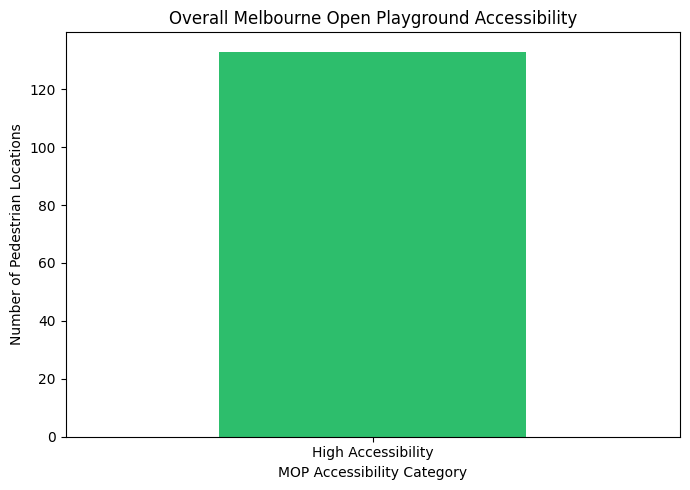

In [34]:
# ------------------------------------------------------------
# Step 4.17: Visualise overall MOP accessibility
# ------------------------------------------------------------

# Count the number of pedestrian locations in each
# overall accessibility category.

mop_accessibility_counts = (
    mop_accessibility["accessibility_category"]
    .value_counts()
)

# Create a bar chart
mop_accessibility_counts.plot(
    kind="bar",
    figsize=(7, 5),
    color="#2DBE6C"
)

plt.xlabel("MOP Accessibility Category")
plt.ylabel("Number of Pedestrian Locations")
plt.title("Overall Melbourne Open Playground Accessibility")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [35]:
# ------------------------------------------------------------
# Step 4.18: Create the final MOP accessibility results table
# ------------------------------------------------------------

# Select the key information required for the final analysis.

final_mop_results = mop_accessibility[
    [
        "latitude",
        "longitude",
        "open_space_score",
        "amenity_score",
        "tree_canopy_score",
        "MOP_accessibility_score",
        "accessibility_category"
    ]
].copy()

# Display the first five results
print(final_mop_results.head())

    latitude   longitude  open_space_score  amenity_score  tree_canopy_score  \
0 -37.813494  144.965153                 3              3                  3   
1 -37.813807  144.965167                 3              3                  3   
2 -37.811015  144.964295                 3              3                  3   
3 -37.814880  144.966088                 3              3                  3   
4 -37.818742  144.967877                 3              3                  3   

   MOP_accessibility_score accessibility_category  
0                        9     High Accessibility  
1                        9     High Accessibility  
2                        9     High Accessibility  
3                        9     High Accessibility  
4                        9     High Accessibility  


In [36]:
# ------------------------------------------------------------
# Step 4.19: Correctly combine accessibility scores
# ------------------------------------------------------------

# Start with the pedestrian locations
mop_accessibility = geoPed_data[
    ["latitude", "longitude"]
].copy()

# Add the open-space scores using the pedestrian index
mop_accessibility["open_space_score"] = (
    ped_openSpace_access["open_space_score"]
    .reindex(mop_accessibility.index)
    .values
)

# Add the amenity scores using the pedestrian index
mop_accessibility["amenity_score"] = (
    ped_amenities_access["amenity_score"]
    .reindex(mop_accessibility.index)
    .values
)

# Add the tree-canopy scores using the pedestrian index
mop_accessibility["tree_canopy_score"] = (
    tree_access["tree_canopy_score"]
    .reindex(mop_accessibility.index)
    .values
)

# Calculate the overall MOP accessibility score
mop_accessibility["MOP_accessibility_score"] = (
    mop_accessibility["open_space_score"]
    + mop_accessibility["amenity_score"]
    + mop_accessibility["tree_canopy_score"]
)

# Display the results
print(mop_accessibility.head(10))

        latitude   longitude  open_space_score  amenity_score  \
0     -37.813494  144.965153                 3              3   
8811  -37.813807  144.965167                 3              3   
17457 -37.811015  144.964295                 3              3   
27567 -37.814880  144.966088                 3              3   
37659 -37.818742  144.967877                 3              3   
39921 -37.819074  144.965579                 3              3   
48763 -37.822935  144.947175                 3              2   
54255 -37.819830  144.951026                 3              3   
62122 -37.818765  144.947105                 3              3   
67908 -37.815667  144.939744                 3              3   

       tree_canopy_score  MOP_accessibility_score  
0                      3                        9  
8811                   3                        9  
17457                  3                        9  
27567                  3                        9  
37659                  3

In [37]:
# ------------------------------------------------------------
# Step 4.20: Handle locations with no nearby amenity or
# tree-canopy feature
# ------------------------------------------------------------

# If no amenity was found for a pedestrian location,
# assign a score of 0 (Poor accessibility).

mop_accessibility["amenity_score"] = (
    mop_accessibility["amenity_score"].fillna(0)
)

# If no tree canopy was found,
# assign a score of 0 (Poor accessibility).

mop_accessibility["tree_canopy_score"] = (
    mop_accessibility["tree_canopy_score"].fillna(0)
)

# Recalculate the overall MOP accessibility score.

mop_accessibility["MOP_accessibility_score"] = (
    mop_accessibility["open_space_score"]
    + mop_accessibility["amenity_score"]
    + mop_accessibility["tree_canopy_score"]
)

# Check the final scores.

print(mop_accessibility.head(10))

        latitude   longitude  open_space_score  amenity_score  \
0     -37.813494  144.965153                 3              3   
8811  -37.813807  144.965167                 3              3   
17457 -37.811015  144.964295                 3              3   
27567 -37.814880  144.966088                 3              3   
37659 -37.818742  144.967877                 3              3   
39921 -37.819074  144.965579                 3              3   
48763 -37.822935  144.947175                 3              2   
54255 -37.819830  144.951026                 3              3   
62122 -37.818765  144.947105                 3              3   
67908 -37.815667  144.939744                 3              3   

       tree_canopy_score  MOP_accessibility_score  
0                      3                        9  
8811                   3                        9  
17457                  3                        9  
27567                  3                        9  
37659                  3

In [39]:
# ------------------------------------------------------------
# Check the distribution of overall MOP accessibility scores
# ------------------------------------------------------------

# Count how many pedestrian locations received each
# overall MOP accessibility score.

score_distribution = (
    final_mop_results["MOP_accessibility_score"]
    .value_counts()
    .sort_index()
)

print(score_distribution)

MOP_accessibility_score
8     13
9    120
Name: count, dtype: int64


In [43]:
# ------------------------------------------------------------
# Prepare final MOP GeoDataFrame for mapping
# ------------------------------------------------------------

# Create a GeoDataFrame from the final accessibility results
# using the original pedestrian geometry.

final_mop_geo = gpd.GeoDataFrame(
    mop_accessibility.copy(),
    geometry=geoPed_data.loc[mop_accessibility.index, "geometry"],
    crs=geoPed_data.crs
)

print("Final MOP GeoDataFrame:")
print(final_mop_geo.head())

print("\nColumns:")
print(final_mop_geo.columns)

Final MOP GeoDataFrame:
        latitude   longitude  open_space_score  amenity_score  \
0     -37.813494  144.965153                 3              3   
8811  -37.813807  144.965167                 3              3   
17457 -37.811015  144.964295                 3              3   
27567 -37.814880  144.966088                 3              3   
37659 -37.818742  144.967877                 3              3   

       tree_canopy_score  MOP_accessibility_score accessibility_category  \
0                      3                        9     High Accessibility   
8811                   3                        9     High Accessibility   
17457                  3                        9     High Accessibility   
27567                  3                        9     High Accessibility   
37659                  3                        9     High Accessibility   

                          geometry  
0      POINT (144.96515 -37.81349)  
8811   POINT (144.96517 -37.81381)  
17457  POINT (144

## 4.8 Final MOP Accessibility Map

The final map displays the spatial distribution of the accessibility categories across the analysed pedestrian locations.


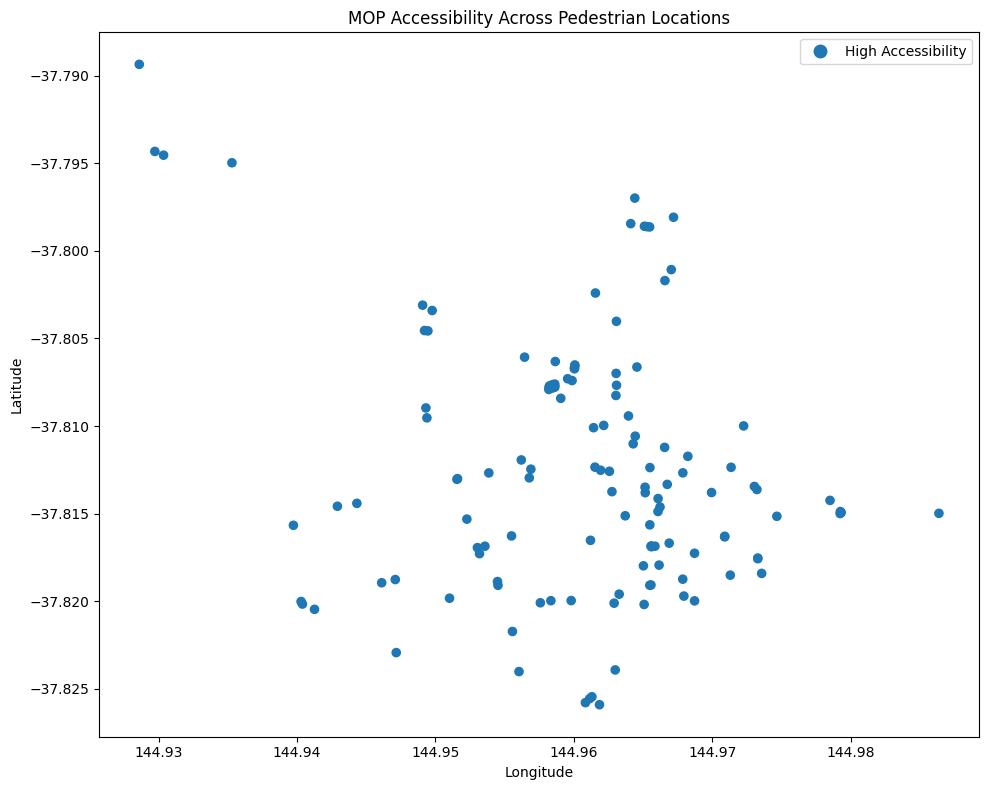

In [45]:
# ------------------------------------------------------------
# Step 4.21: Final MOP accessibility map
# ------------------------------------------------------------

# Create the final accessibility map with readable
# longitude and latitude values.

fig, ax = plt.subplots(figsize=(10, 8))

final_mop_geo.plot(
    column="accessibility_category",
    ax=ax,
    legend=True,
    markersize=35
)

plt.title("MOP Accessibility Across Pedestrian Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Display longitude values normally instead of scientific notation
ax.ticklabel_format(
    style="plain",
    axis="x",
    useOffset=False
)

plt.tight_layout()
plt.show()

# Step 5: Results and Findings

The results of the geospatial accessibility analysis are used to evaluate the overall accessibility of the Melbourne Open Playground (MOP) study area.

In this step, the results are analysed by:

- Comparing the average distance to the nearest open space, public amenity, and tree canopy.
- Examining the distribution of accessibility categories across pedestrian locations.
- Combining individual component scores to determine the overall MOP Accessibility Score.
- Visualising the final accessibility results using charts and a spatial map.
- Interpreting the findings and identifying limitations of the analysis.

The results provide an overall assessment of accessibility across the study area and help identify locations where access to open spaces, amenities, and tree canopy may be comparatively lower.


## 5.1 Overall MOP Accessibility

The final MOP accessibility assessment evaluated 133 pedestrian locations. A total of 120 locations (90.2%) achieved the maximum score of 9/9 and were classified as High Accessibility. The remaining 13 locations (9.8%) received a score of 6/9 and were classified as Moderate Accessibility. No locations were classified as Low Accessibility.

| MOP Accessibility | Score | Number of Locations | Percentage |
|---|---:|---:|---:|
| High Accessibility | 9/9 | 120 | 90.2% |
| Moderate Accessibility | 6/9 | 13 | 9.8% |
| Low Accessibility | 0–3/9 | 0 | 0% |
| **Total** | | **133** | **100%** |


## 5.2 Accessibility to Open Spaces

Open-space accessibility was assessed by calculating the distance from each pedestrian location to the nearest open-space feature, including parks, playgrounds, and pedestrian tracks. The average distance to the nearest open space was 5.7 metres. All 133 pedestrian locations were classified as Excellent accessibility (<100 m).

| Measure | Result |
|---|---:|
| Average distance to nearest open space | 5.7 m |
| Excellent (<100 m) | 133 locations |
| Good (100–250 m) | 0 locations |
| Locations analysed | 133 |


## 5.3 Accessibility to Public Amenities

Public amenity accessibility was assessed using drinking fountains, public washrooms, and public seating. The average distance to the nearest amenity was 35.6 metres. The closest recorded distance was 0.9 metres and the furthest was 245.7 metres. A total of 122 locations were classified as Excellent accessibility (<100 m), while 11 locations were classified as Good accessibility (100–250 m).

| Measure | Result |
|---|---:|
| Average distance to nearest amenity | 35.6 m |
| Excellent (<100 m) | 122 locations |
| Good (100–250 m) | 11 locations |
| Locations analysed | 133 |


## 5.4 Accessibility to Tree Canopy

Tree-canopy accessibility was assessed by calculating the distance from each pedestrian location to the nearest tree-canopy location. The average distance to the nearest tree canopy was 23.5 metres. The closest recorded distance was 0.7 metres and the furthest was 118.2 metres. A total of 131 locations were classified as Excellent accessibility (<100 m), while 2 locations were classified as Good accessibility (100–250 m).

| Measure | Result |
|---|---:|
| Average distance to nearest tree canopy | 23.5 m |
| Excellent (<100 m) | 131 locations |
| Good (100–250 m) | 2 locations |
| Locations analysed | 133 |


## 5.5 Key Findings

Overall, the analysis demonstrates a high level of accessibility across the analysed Melbourne Open Playground study area. Open spaces had the shortest average nearest-feature distance at 5.7 metres, followed by tree canopy at 23.5 metres and public amenities at 35.6 metres.

The final assessment found that 120 locations (90.2%) were classified as High Accessibility and 13 locations (9.8%) were classified as Moderate Accessibility. No locations were classified as Low Accessibility.

These findings indicate that most analysed pedestrian locations have convenient access to surrounding open spaces, public amenities, and tree canopy.


## 5.6 Limitations

The accessibility results depend on the completeness and accuracy of the source datasets. The analysis uses straight-line distance to the nearest feature rather than actual pedestrian network distance, so calculated distances may not always represent the walking distance experienced by pedestrians.

The scoring system also simplifies accessibility into discrete categories and does not account for factors such as facility quality, capacity, condition, safety, or accessibility for people with different mobility requirements.

Where no corresponding amenity or tree-canopy feature was returned by the nearest-feature analysis, a score of 0 was assigned for that component. These cases should therefore be interpreted as limited or unavailable spatial matches within the datasets rather than definitive evidence that no facility or tree canopy exists at that location.
